# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [20]:
!pip install sentencepiece

In [21]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [22]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

I0000 00:00:1789112280.719840 29280575 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: jokes.txt
  input_format: 
  model_prefix: bpe
  model_type: BPE
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_p

In [23]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [24]:
model = LanguageModel(train_set)

In [25]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

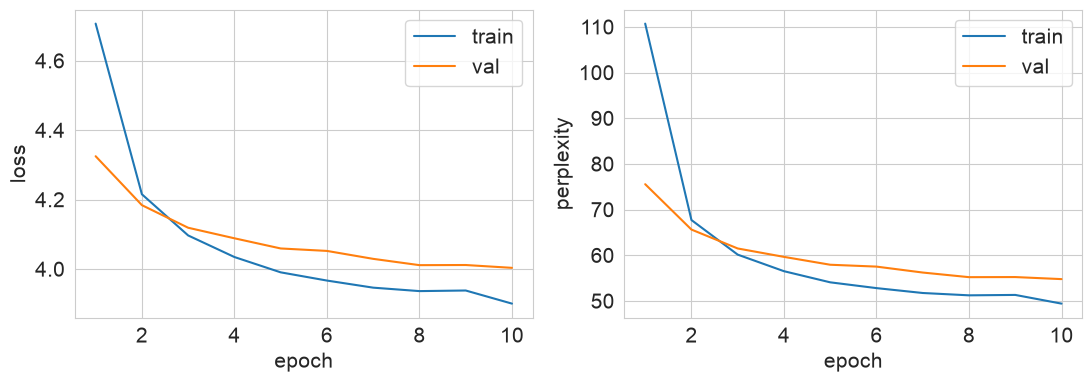

Generation examples:
сидит грзель, чтобы стать весе рассказала до отношение к детского положения мента рекламары поезжали - его красавица!- не понял! умер, ты бессмертем.
- ты кто такой миграл! список банце, чтобы мама заставлять без покупки - ни и свет.
проситрна штирлица. женское пиво.
у которых не говорит, и проявление заколе передают маленького жена.
мысли могут вплоть?


In [30]:
from train import train
from torch import nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

model = LanguageModel(train_set)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = None # StepLR(optimizer, step_size=3, gamma=0.5)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_set, batch_size=32)
num_epochs = 10

train(model, optimizer, scheduler, train_loader, val_loader, num_epochs)

In [31]:
torch.save(model.state_dict(), "rnn_bpe_2000.pt")

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

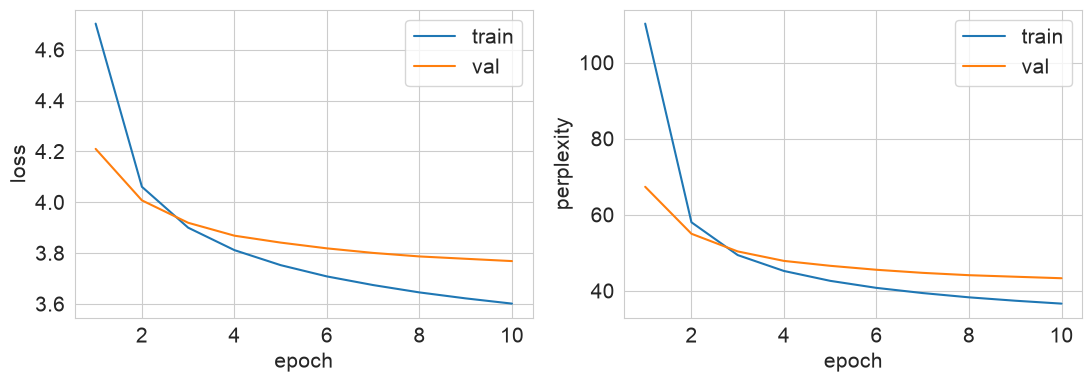

Generation examples:
если у вас, что бы воровать скрывают за курса одежду.
- доченька, ты знаешь, что я пью кофе на аэроду - алкоголем. просто, брат...- мам, дев...- какая, вам подает и удивляешься?- порчу.
прочитав отпусти, верется целый дурак... зайдет, что вы исполнинитесь, французский айфоны под этикета - не устрапу.только ложь, но и на конец, месяц и протукладывают очень к чему голобра.
самочувствий коррупция от премьер-министах матак не издавили жизнь полагать, а помнючит за путина.
перед правым камеркой сердце, для того чтобы любая жена гроба ну прибили меня не пробура.


In [32]:
model = LanguageModel(train_set, rnn_type=nn.LSTM)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = None # StepLR(optimizer, step_size=3, gamma=0.5)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_set, batch_size=32)
num_epochs = 10
train(model, optimizer, scheduler, train_loader, val_loader, num_epochs)

In [33]:
torch.save(model.state_dict(), "lstm_bpe_2000.pt")

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [34]:
rnn_model = LanguageModel(train_set)
lstm_model = LanguageModel(train_set, rnn_type=nn.LSTM)

rnn_model.load_state_dict(torch.load("rnn_bpe_2000.pt"))
lstm_model.load_state_dict(torch.load("lstm_bpe_2000.pt"))

<All keys matched successfully>

In [35]:
temperatures = [0.2, 0.5, 1.0, 1.5, 2.0]

prefixes = [
    "купил мужик",
    "сел медведь в машину и",
    "подумал штирлиц",
    "однажды утром"
]

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model
}

for prefix in prefixes:
    print(f"\n{'=' * 80}")
    print(f"PREFIX: {prefix}")
    print('=' * 80)

    for temp in temperatures:
        print(f"\nTemperature: {temp}")

        for model_name, model in models.items():
            generated = model.inference(prefix=prefix, temp=temp)
            print(f"{model_name}: {generated}")


PREFIX: купил мужик

Temperature: 0.2
RNN: купил мужик в магазин, а ты нашел в магазин, а потом на него и говорит- ты что, не надо, чтобы ты не знаешь, что я не могу.
LSTM: купил мужик в магазин и говорит- ну, как тебе, а ты знаешь, что ты знаешь, что ты с тобой на улице?- да, но я не могу.

Temperature: 0.5
RNN: купил мужик, сэр, приехал в магазин, забивает сборной россии в россии по футболу, а в центре москвы.
LSTM: купил мужик и говорит жене- ну что, включишь, что ли?- ну, конечно, я знаю, что ты там делаешь!

Temperature: 1.0
RNN: купил мужик 5 стало собаками. подходит источник или сотрудника торгуляции заявляет девушке, а другой с радиособами, гуляют фразы - это сделать, куда? называются со столчасти купаю с мужчиной.
LSTM: купил мужик, вздохнув в дом и говорит- хорошо... а вот только одна - такого маленький бабье.

Temperature: 1.5
RNN: купил мужик - плочего, пожалуйста, дочь его там месяце само время гриворим несколько мачные свадьки?- мало кто знает много все спля останови опь

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [36]:
train_set_bpe_large = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe_5000", vocab_size=5000)
valid_set_bpe_large = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe_5000", vocab_size=5000)

I0000 00:00:1789121016.351433 29280575 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: jokes.txt
  input_format: 
  model_prefix: bpe_5000
  model_type: BPE
  vocab_size: 5000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_different

In [37]:
train_loader = DataLoader(train_set_bpe_large, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_set_bpe_large, batch_size=32)

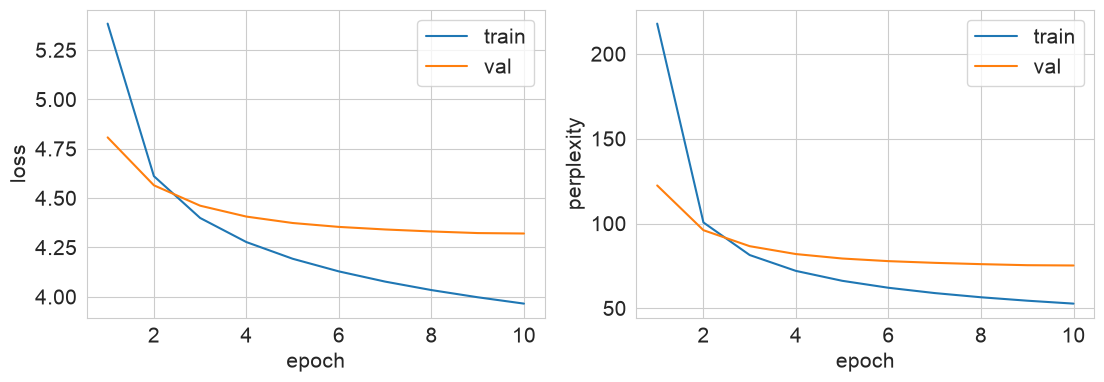

Generation examples:
- девушки, да.- облегняя рука. нищен этажом выше.- да?- ты в такой машине не похож! вон, еда-гей, все, а трусиосиивай!
если в лесу был биатлон, а вода - будьте. двоито якурив рассказывала, очередь изнской туподорогу, вот замечательно у него голая девушка с темпераким антибиоматом ня определи нести щекотался.
- иногда три женщины вам пятеры каждые сколько любить нельзя, я начинаю с ним целовать мне...
у меня полно эффекты - наркозрудно навязчика коротенький проект семен.
следует, дай сигаретку.нолог говорит трое, когда смелый, как и неадестет. взять полтора.- психиатр ты в наших отношениях любишь!- кажется, я согласна, когда выходишь?


In [38]:
model = LanguageModel(train_set_bpe_large, rnn_type=nn.LSTM)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
num_epochs = 10

train(model, optimizer, scheduler, train_loader, val_loader, num_epochs)
torch.save(model.state_dict(), "lstm_bpe_5000.pt")

In [39]:
train_set_unigram = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="unigram_2000", vocab_size=2000, model_type="unigram")
valid_set_unigram = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="unigram_2000", vocab_size=2000, model_type="unigram")

I0000 00:00:1789124578.452980 29280575 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: jokes.txt
  input_format: 
  model_prefix: unigram_2000
  model_type: UNIGRAM
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_d

In [40]:
train_loader = DataLoader(train_set_unigram, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_set_unigram, batch_size=32)

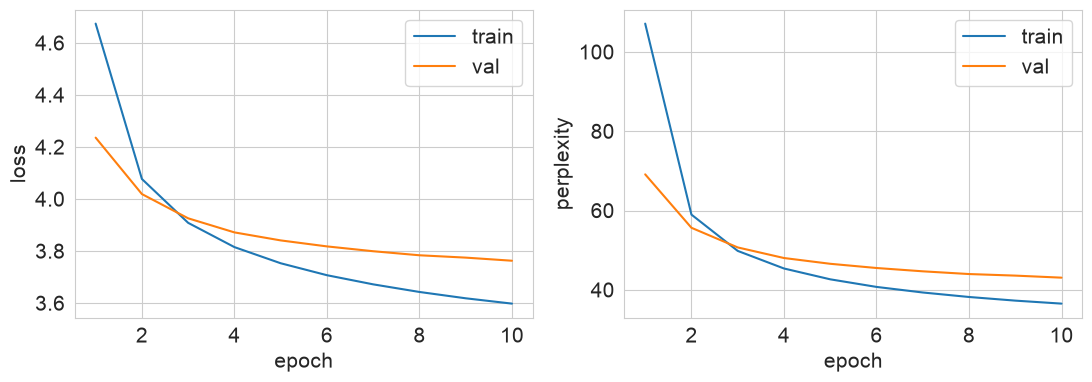

Generation examples:
россия пытается узнано выбирать лишь фотографий богипорт на ночь и креативности электрошенной обнаженной туалетной бумаги. один из поджидался по паспорту, он николко и двух раздол мужей.
гуляю с пересадением во времени - не так хорошо быть и в голове моя подряд, это в китаенная невероятный возраст среди на тему шансов больше неплощалось!
- мафий омерял- по-моему не менее дача, я исполнююсь, концертуальная во корьбело сильный.
не вычеривает у соседа, если меня ругачь стараться приходит то, на который они спрашивают, то женатая, то с диктатором и огромным поколение идиотом и две не ушла.
звонок в офис и спрашивает дьявог- стать раком в полной печатате?- нет, только распутывать - из банковскую крики на меня!


In [41]:
model = LanguageModel(train_set_unigram, rnn_type=nn.LSTM)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
num_epochs = 10

train(model, optimizer, scheduler, train_loader, val_loader, num_epochs)
torch.save(model.state_dict(), "lstm_unigram_2000.pt")

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


def lsa_analysis(real_texts, generated_texts, n_components=100):
    all_texts = real_texts + generated_texts

    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform(all_texts)

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    embeddings = svd.fit_transform(tfidf)

    n_real = len(real_texts)

    real_embeddings = embeddings[:n_real]
    generated_embeddings = embeddings[n_real:]

    similarities = cosine_similarity(
        generated_embeddings,
        real_embeddings
    )

    best_similarities = similarities.max(axis=1)
    score = best_similarities.mean()

    return score, real_embeddings, generated_embeddings

In [46]:
model_1 = LanguageModel(train_set, rnn_type=nn.LSTM)
model_2 = LanguageModel(train_set_bpe_large, rnn_type=nn.LSTM)
model_3 = LanguageModel(train_set_unigram, rnn_type=nn.LSTM)

model_1.load_state_dict(torch.load("lstm_bpe_2000.pt"))
model_2.load_state_dict(torch.load("lstm_bpe_5000.pt"))
model_3.load_state_dict(torch.load("lstm_unigram_2000.pt"))

models = {
    "BPE 2000": (model_1, valid_set),
    "BPE 5000": (model_2, valid_set_bpe_large),
    "Unigram 2000": (model_3, valid_set_unigram),
}

results = {}

for name, (model, dataset) in models.items():
    real_texts = []
    generated_texts = []

    for i in range(len(dataset)):
        indices, length = dataset[i]

        real_text = dataset.sp_model.decode(indices[:length].tolist())
        generated_text = model.inference(temp=1.0)
        real_texts.append(real_text)
        generated_texts.append(generated_text)

    score, real_embeddings, generated_embeddings = lsa_analysis(real_texts, generated_texts)

    results[name] = {
        "score": score,
        "real_embeddings": real_embeddings,
        "generated_embeddings": generated_embeddings,
        "real_texts": real_texts,
        "generated_texts": generated_texts,
    }

    print(name, score)

BPE 2000 0.7331217400095689
BPE 5000 0.731401553753985
Unigram 2000 0.7305189841627956


## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

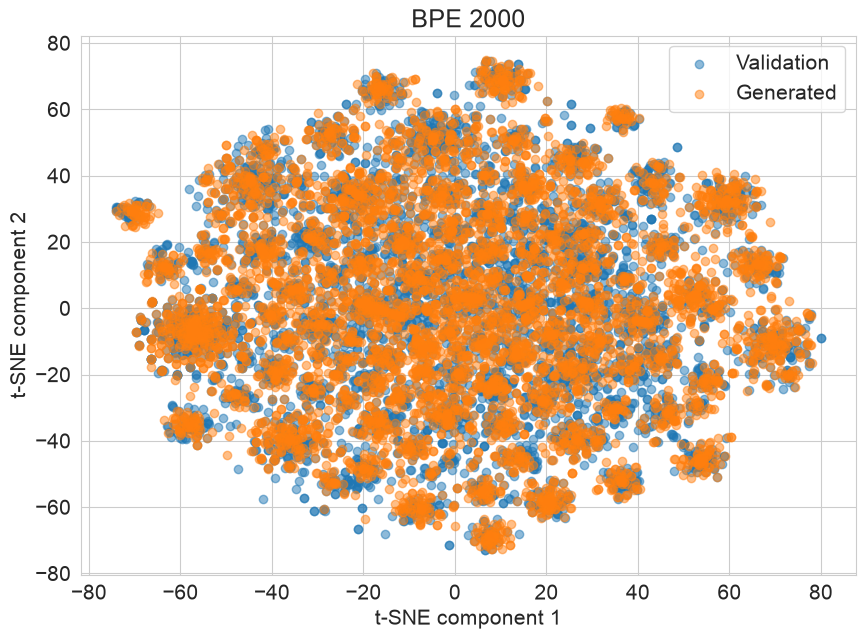

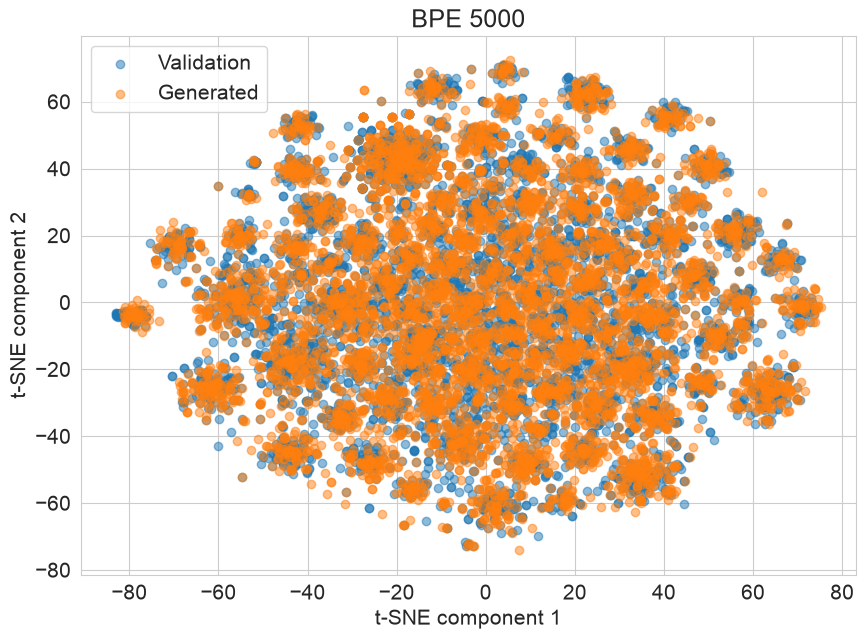

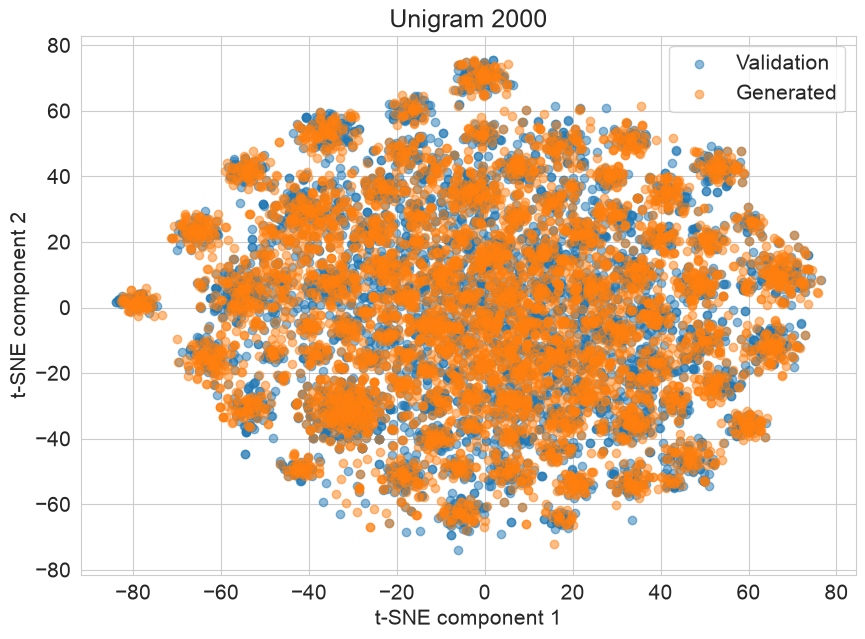

In [47]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


for name, result in results.items():
    real_embeddings = result["real_embeddings"]
    generated_embeddings = result["generated_embeddings"]

    all_embeddings = np.vstack([
        real_embeddings,
        generated_embeddings
    ])

    tsne = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )

    embeddings_2d = tsne.fit_transform(all_embeddings)

    n_real = len(real_embeddings)

    real_2d = embeddings_2d[:n_real]
    generated_2d = embeddings_2d[n_real:]

    plt.figure(figsize=(10, 7))

    plt.scatter(
        real_2d[:, 0],
        real_2d[:, 1],
        alpha=0.5,
        label="Validation"
    )

    plt.scatter(
        generated_2d[:, 0],
        generated_2d[:, 1],
        alpha=0.5,
        label="Generated"
    )

    plt.title(name)
    plt.xlabel("t-SNE component 1")
    plt.ylabel("t-SNE component 2")
    plt.legend()
    plt.show()

## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [50]:
import math
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm


MODEL_NAME = "ai-forever/rugpt3small_based_on_gpt2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

rugpt = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
rugpt = rugpt.to(device)
rugpt.eval()


@torch.no_grad()
def calculate_perplexity(text: str) -> float:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=tokenizer.model_max_length
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    outputs = rugpt(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=input_ids
    )

    loss = outputs.loss

    perplexity = torch.exp(loss)

    return perplexity.item()


def evaluate_texts_perplexity(texts):
    perplexities = []

    for text in tqdm(texts):
        if not text.strip():
            continue

        ppl = calculate_perplexity(text)
        perplexities.append(ppl)

    return {
        "mean": sum(perplexities) / len(perplexities),
        "median": sorted(perplexities)[len(perplexities) // 2],
        "perplexities": perplexities
    }


ppl_results = {}

for name, result in results.items():
    generated_texts = result["generated_texts"]

    metrics = evaluate_texts_perplexity(generated_texts)

    ppl_results[name] = metrics

    print(
        f"{name}: "
        f"mean perplexity = {metrics['mean']:.2f}, "
        f"median perplexity = {metrics['median']:.2f}"
    )

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 21047.80it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
100%|██████████| 6038/6038 [04:03<00:00, 24.83it/s]


BPE 2000: mean perplexity = 2728.10, median perplexity = 1678.18


100%|██████████| 6038/6038 [03:51<00:00, 26.13it/s]


BPE 5000: mean perplexity = 2302.59, median perplexity = 1348.97


100%|██████████| 6038/6038 [03:40<00:00, 27.35it/s]

Unigram 2000: mean perplexity = 2871.34, median perplexity = 1801.55
